# Analysis of MNase-seq replication timing

March 29, 2024

Updated replication timing analysis with realigned 60 minute BAM



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [32]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [33]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

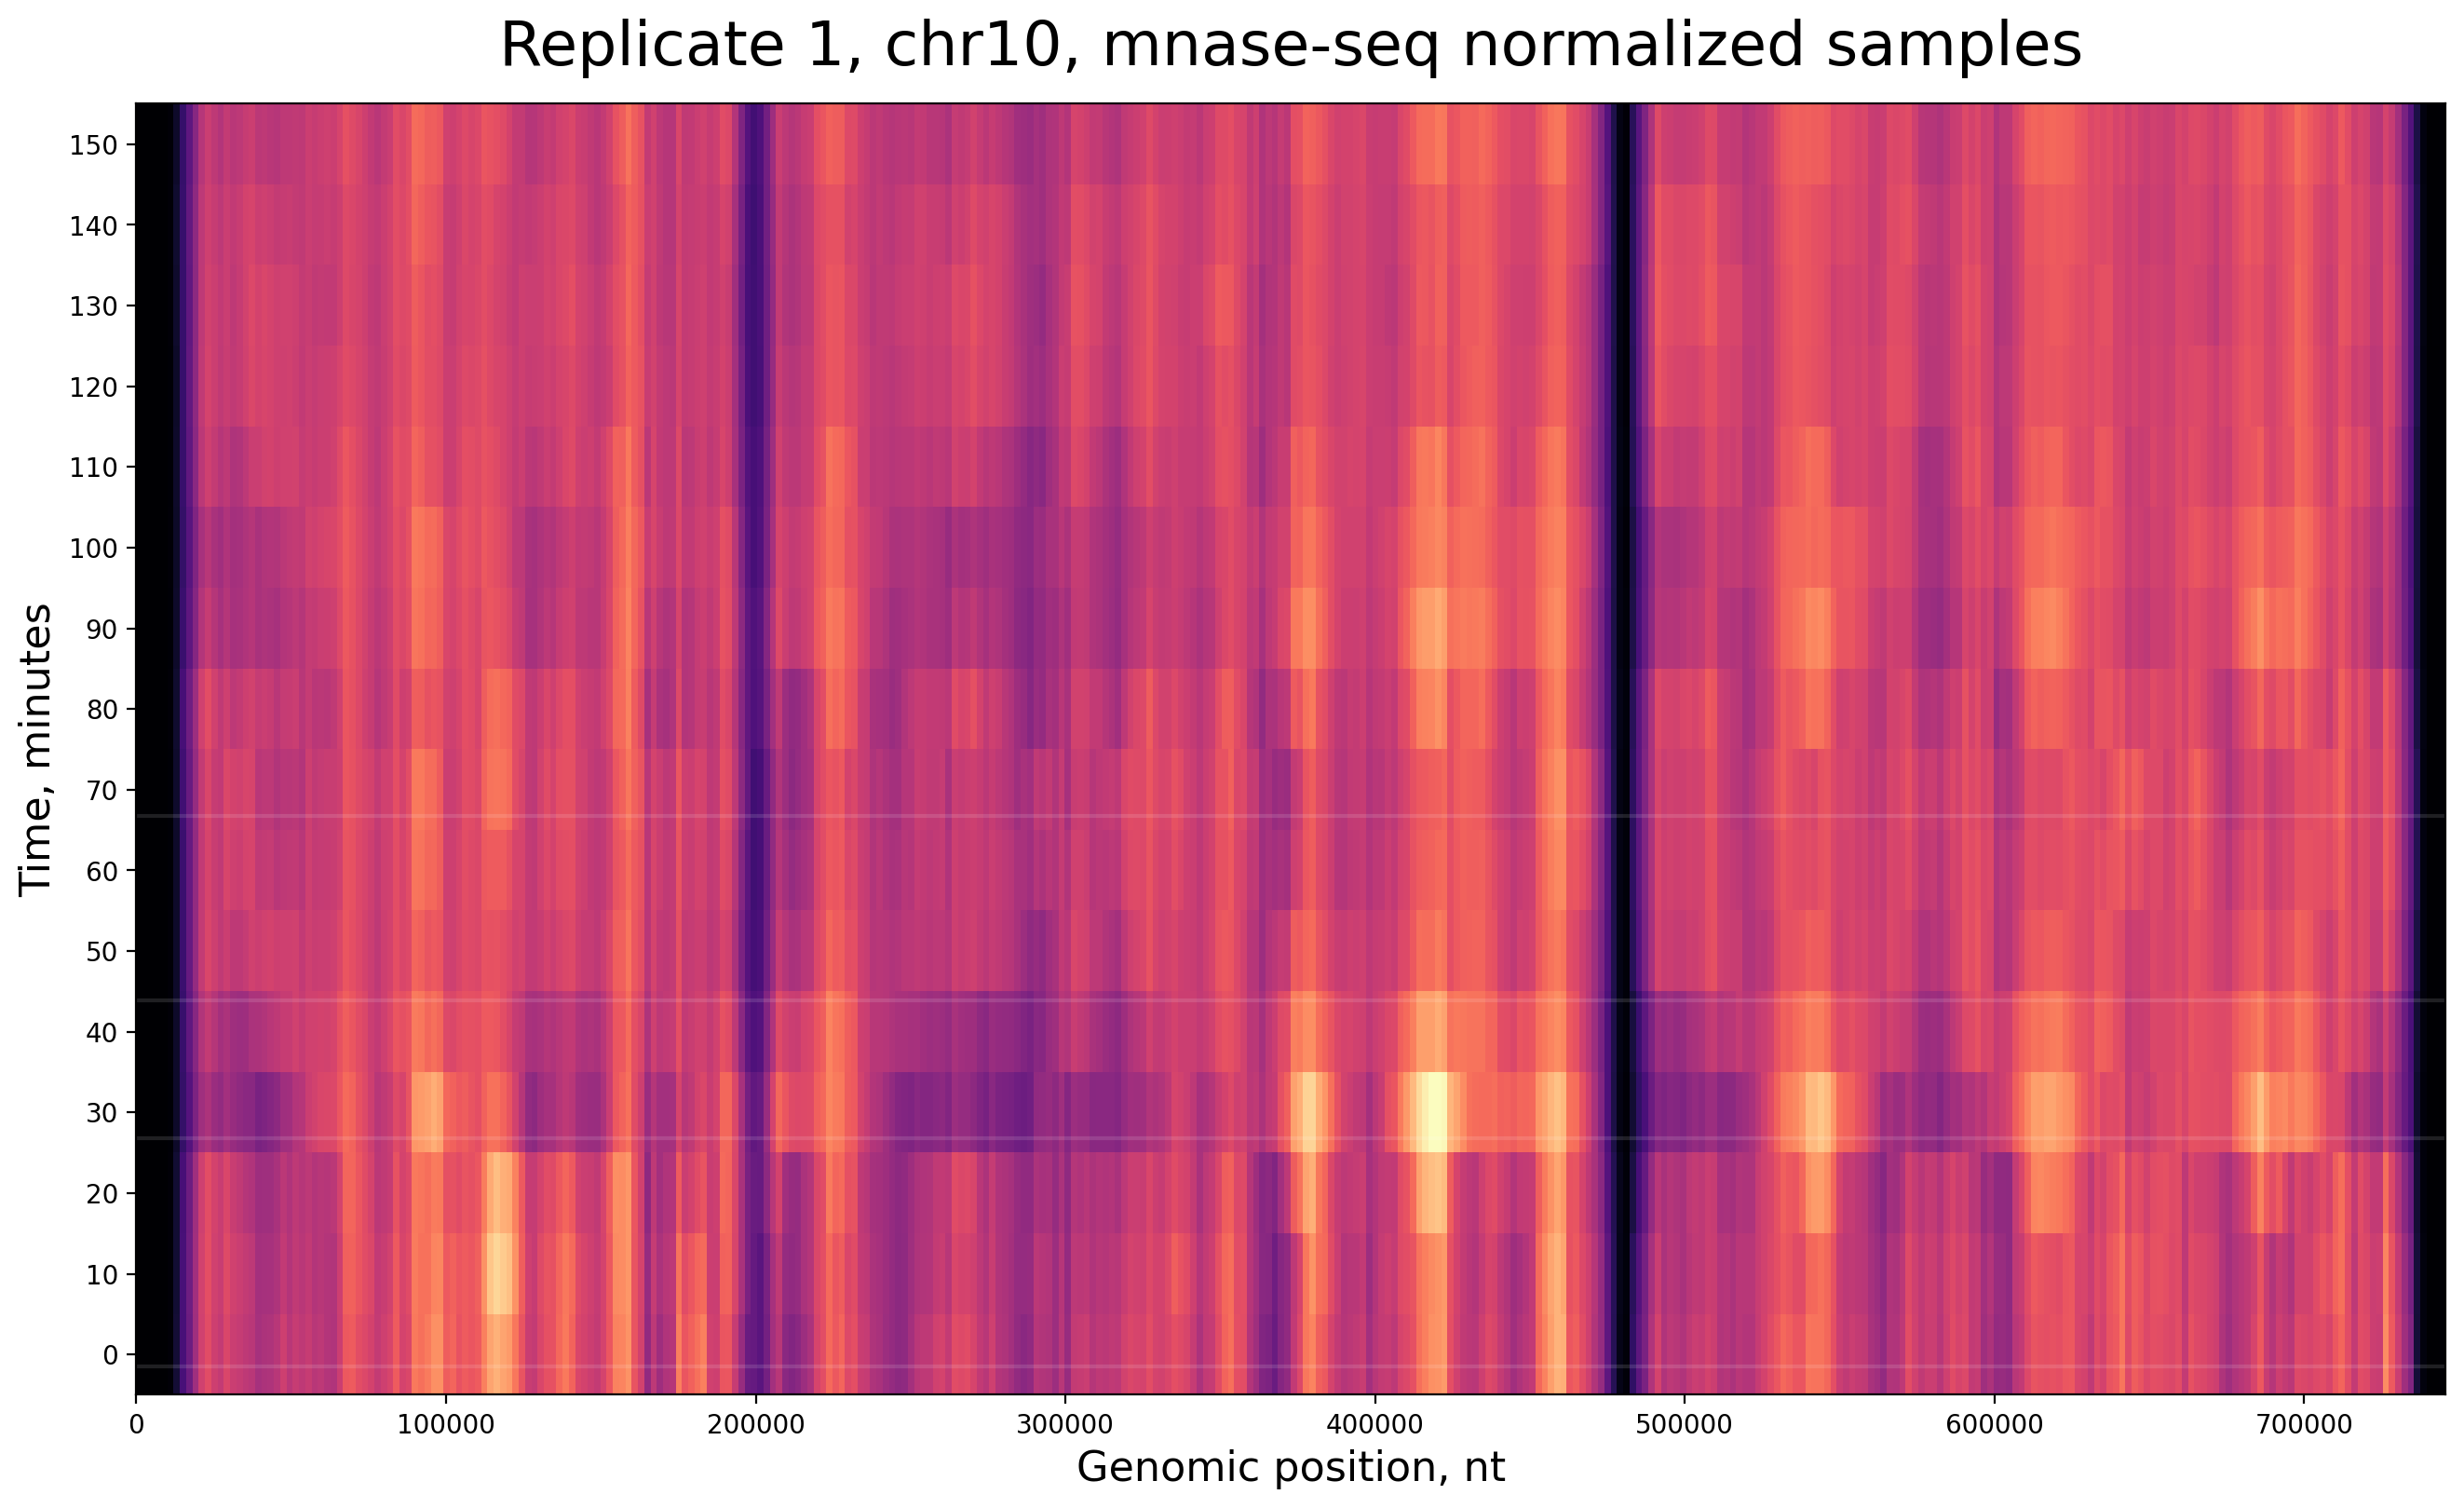

In [36]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=False)

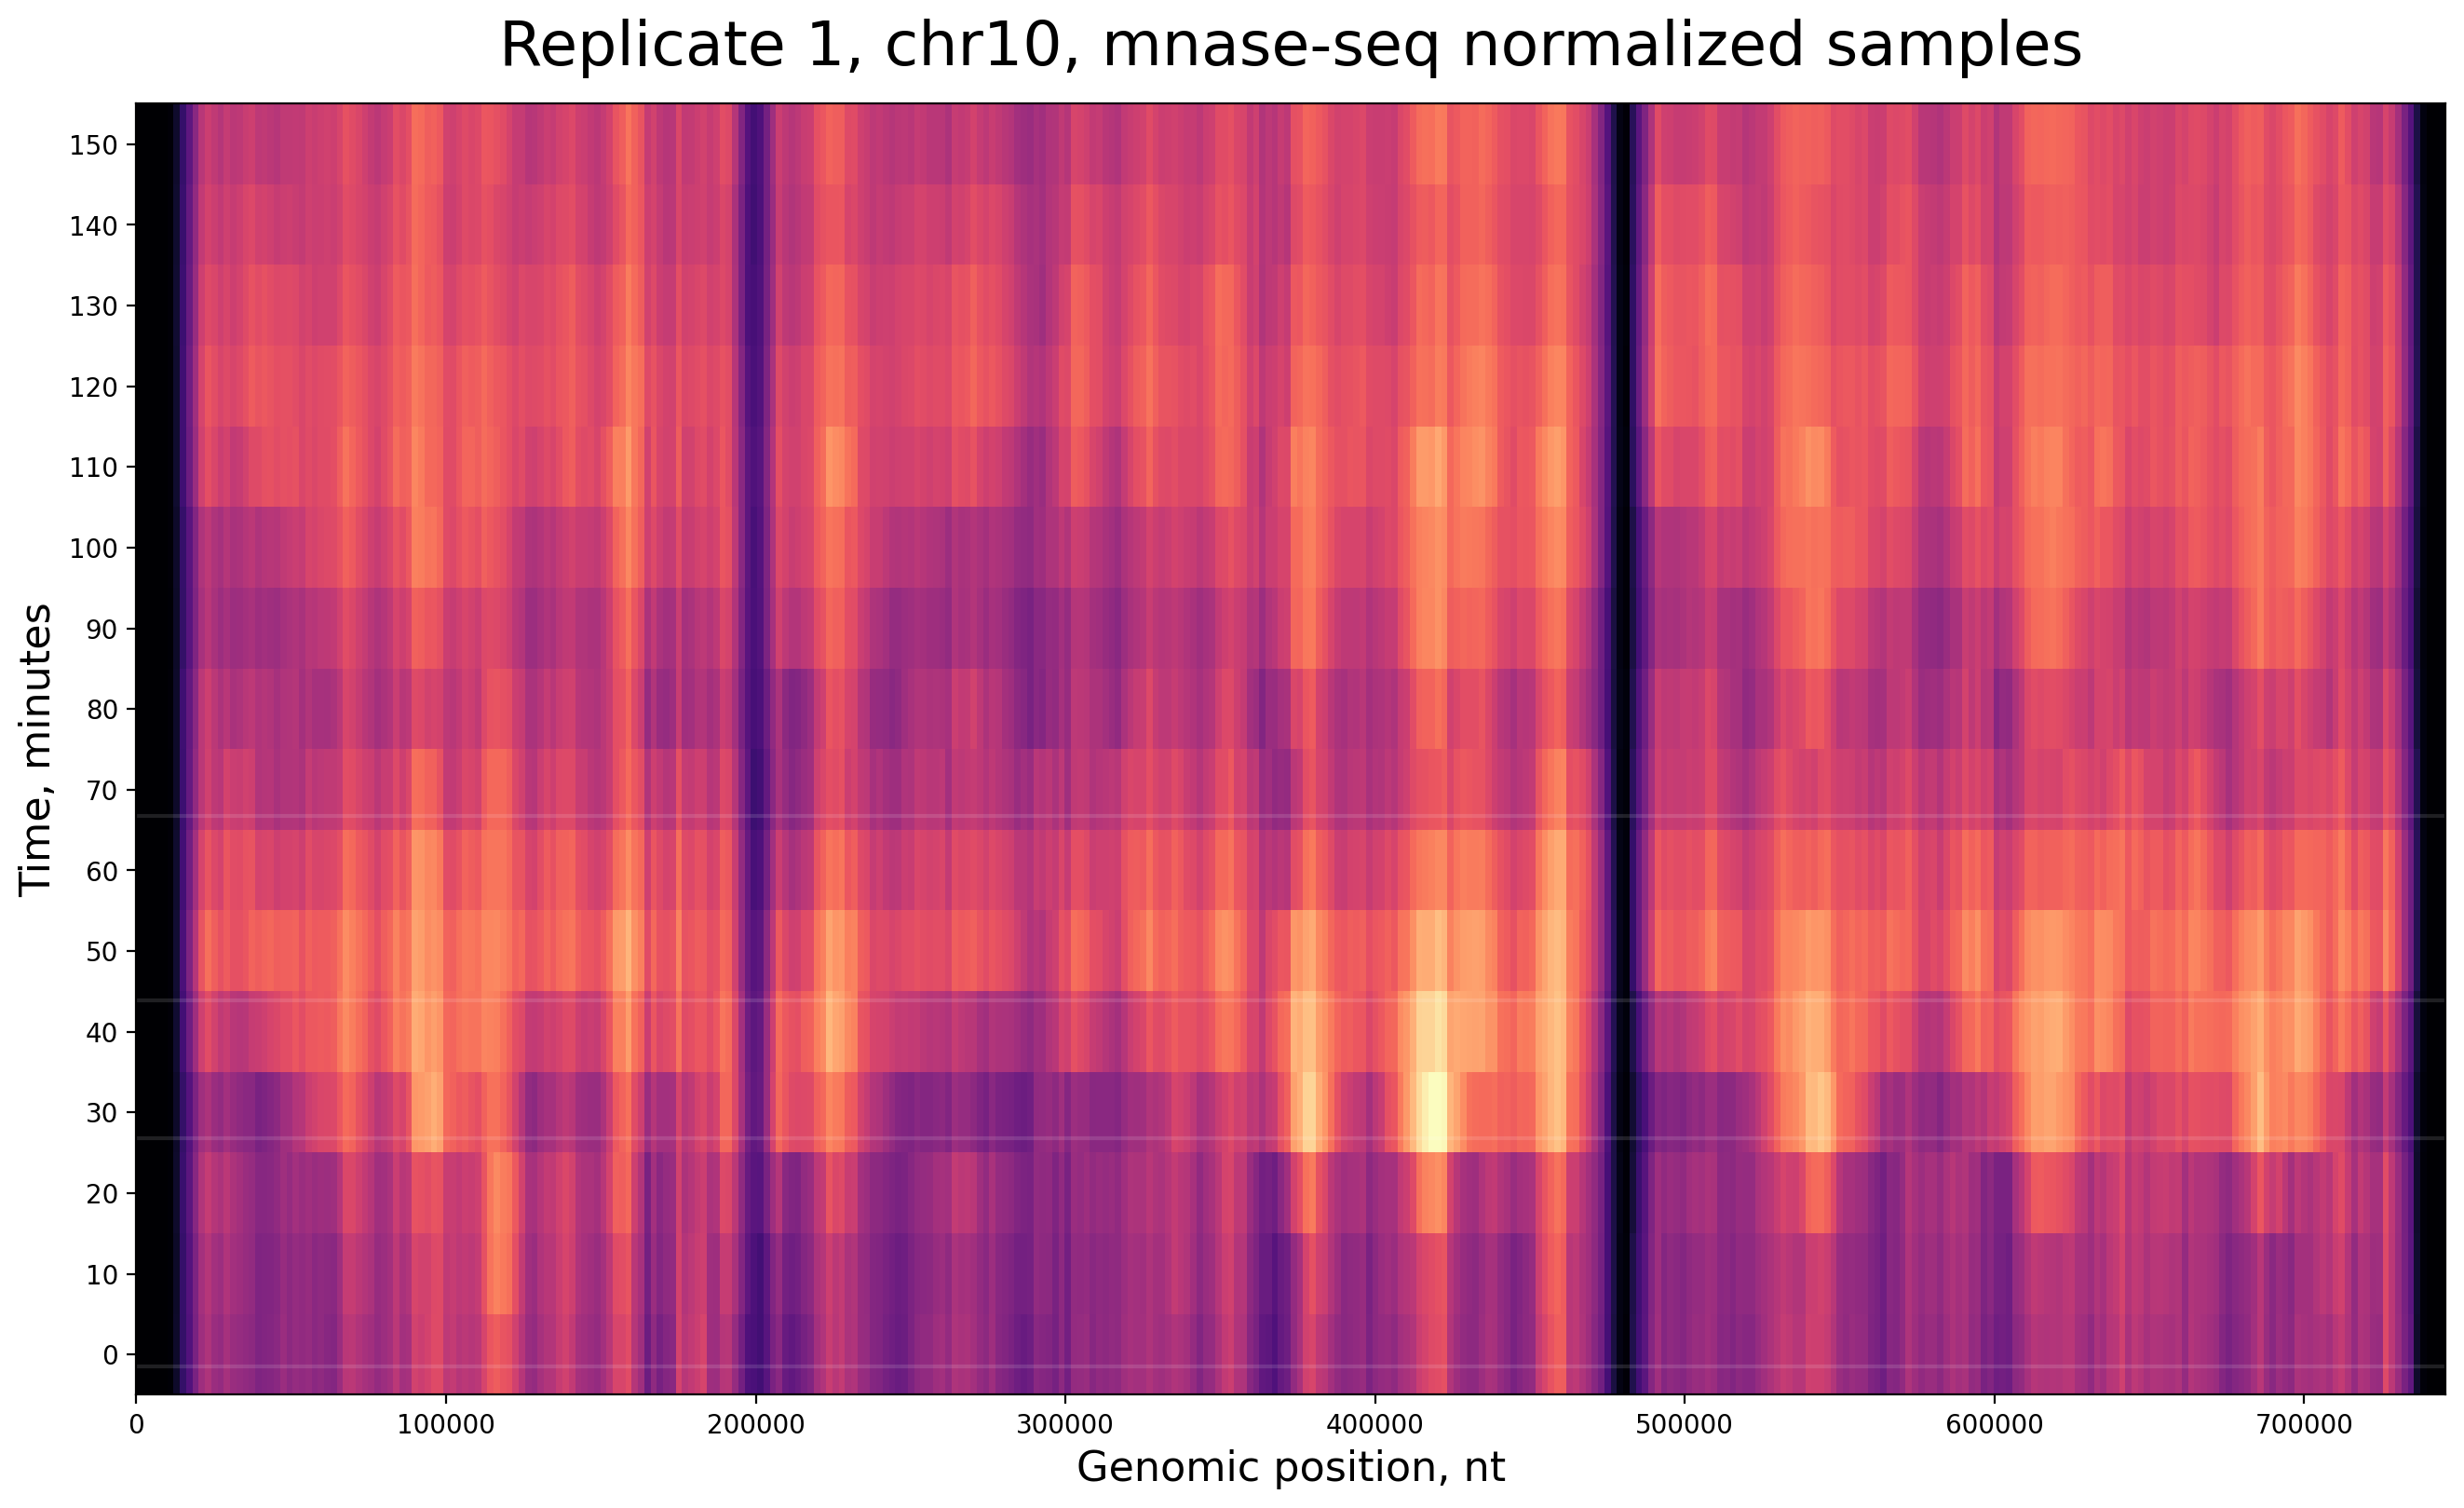

In [34]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

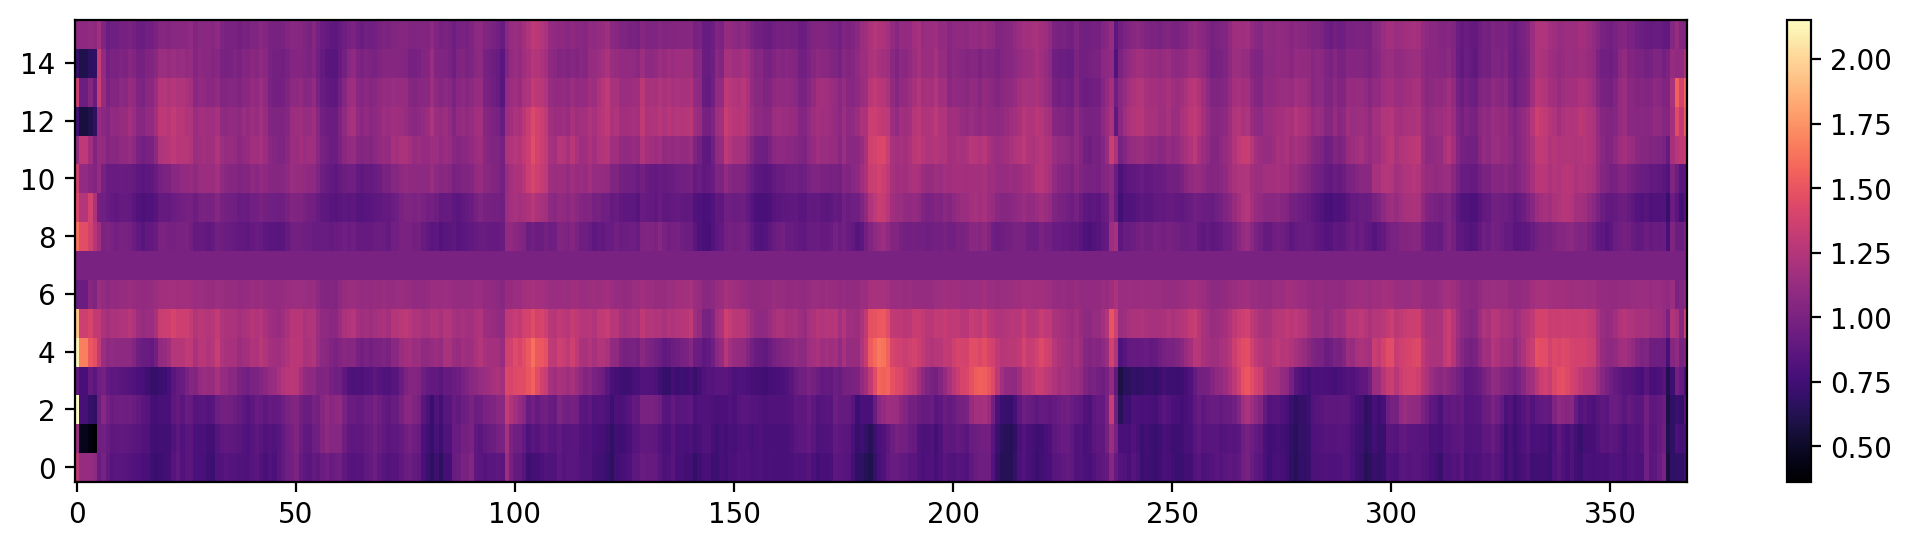

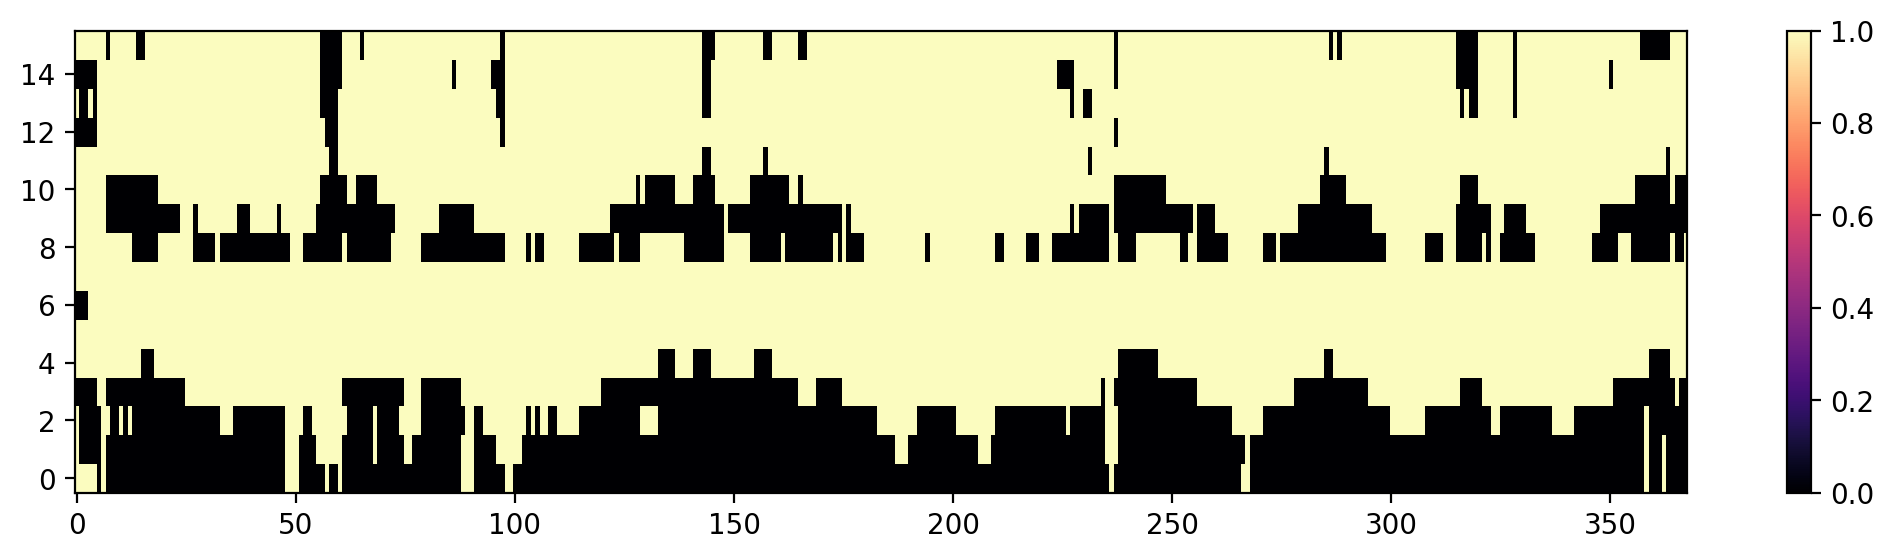

In [44]:
testing_normalize_by_end_of_cc = mnase_analysis.counts_normalized_by_copy.copy()
testing_normalize_by_end_of_cc /= testing_normalize_by_end_of_cc[7]

plt.figure(figsize=(13, 3))
plt.imshow(testing_normalize_by_end_of_cc, origin='lower', aspect='auto', cmap='magma')
plt.colorbar()

plt.figure(figsize=(13, 3))
plt.imshow(testing_normalize_by_end_of_cc > .95, origin='lower', aspect='auto', cmap='magma')
plt.colorbar()
